# Bias in Bios: Cost-Aware CLAQ Experiment

This experiment evaluates cost-aware adaptive querying in the Bias-in-Bios text setting.

Two query-cost specifications are considered:

- **Uniform query-count cost** `C(q) = 1`. Cumulative cost equals the number of executed
  queries. The expected-cost term is constant across query choices and therefore does not
  alter their relative ordering.
- **Synthetic response-uncertainty cost** `C(q) = 1 + D(q)`, where `D(q)` is the normalized
  predictive entropy of the soft Concept-QA response model averaged over a calibration
  split. Queries with less certain responses receive higher costs.

Cost is incorporated at two stages:

1. **Training** — the objective includes the expected cumulative cost of the adaptive
   training transcript, weighted by `lambda_c`.
2. **Inference** — the cost-feasible candidate set excludes queries that would exceed the
   remaining cumulative-cost budget before the policy makes a hard selection.

The pretrained CLIP and Concept-QA response models remain fixed. Each experimental run
trains the actor, task classifier, and auxiliary sensitive head.


In [1]:
import copy
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from sentence_transformers import SentenceTransformer
from sklearn.metrics import accuracy_score, f1_score
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm


def find_repo_root(start_path):
    start_path = Path(start_path).resolve()
    for candidate in [start_path, *start_path.parents]:
        if (candidate / "assets" / "concepts" / "bias_in_bios.csv").exists():
            return candidate
    raise FileNotFoundError("Could not find repo root from current working directory")


repo_root = find_repo_root(Path.cwd())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from claq.analysis.rollouts import rollout_until_confidence
from claq.core import apply_query_distribution
from claq.core.cost import build_uncertainty_cost, build_uniform_cost, expected_query_cost, normalized_binary_entropy
from claq.models import ConceptAnswererMLP, Network
from claq.training import GradientReversal, HistorySamplingConfig, sample_history_mask, seed_everything

SEEDS = (0, 1, 2, 3, 4)
seed_everything(SEEDS[0])

sample_dir = repo_root / "artifacts" / "data" / "bias_in_bios_sample"
concepts_path = repo_root / "assets" / "concepts" / "bias_in_bios.csv"
labels_wide_path = sample_dir / "labels_wide_test_train_validation.csv"
qa_checkpoint_path = repo_root / "artifacts" / "models" / "concept_qa_bias_in_bios_concept_answerer_mlp_openai_labels.pt"
runs_dir = repo_root / "artifacts" / "runs"
runs_dir.mkdir(parents=True, exist_ok=True)

SPLITS = ["train", "validation", "test"]
TEXT_COLUMN = "hard_text"
MAX_QUESTIONS = 20
TRAIN_ROLLOUT_STEPS = MAX_QUESTIONS
CALIBRATION_SIZE = 1000
DESIGNATED_QUERY_WEIGHT = 1.0
NUM_EPOCHS = 50
BATCH_SIZE = 256
LEARNING_RATE = 1e-3
ACTOR_EPS_START = 1.0
ACTOR_EPS_END = 0.2
TRAIN_MIN_HISTORY = 0
TRAIN_MAX_HISTORY = 20

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
str(device)


'cuda'

In [2]:
concepts_df = pd.read_csv(concepts_path)
concept_names = concepts_df["concept"].tolist()
labels_wide = pd.read_csv(labels_wide_path)

split_frames = {}
for split in SPLITS:
    samples = pd.read_csv(sample_dir / f"{split}.csv").reset_index(names="sample_row")
    labels = labels_wide.loc[labels_wide["split"].eq(split)].copy()
    merged = samples.merge(
        labels[["sample_row", "source_index", *concept_names]],
        on=["sample_row", "source_index"],
        how="inner",
        validate="one_to_one",
    )
    if len(merged) != len(samples):
        raise ValueError(f"Merged {len(merged)} rows for {split}, expected {len(samples)}")
    split_frames[split] = merged

profession_id_to_name = (
    split_frames["train"][["profession", "profession_name"]]
    .drop_duplicates()
    .sort_values("profession")
    .set_index("profession")["profession_name"]
    .to_dict()
)
num_professions = len(profession_id_to_name)
class_names = [profession_id_to_name[i] for i in range(num_professions)]

y_by_split = {split: frame["profession"].to_numpy(dtype=int) for split, frame in split_frames.items()}
s_by_split = {split: frame["gender"].to_numpy(dtype=np.float32) for split, frame in split_frames.items()}

{
    "split_rows": {split: len(frame) for split, frame in split_frames.items()},
    "num_professions": num_professions,
    "num_concepts": len(concept_names),
}


{'split_rows': {'train': 10000, 'validation': 1000, 'test': 2000},
 'num_professions': 28,
 'num_concepts': 58}

In [3]:
checkpoint = torch.load(qa_checkpoint_path, map_location=device, weights_only=False)
encoder_name = checkpoint["encoder_name"]
model_config = checkpoint["model_config"]
model_config["hidden_dims"] = tuple(model_config["hidden_dims"])
concept_embeddings = checkpoint["concept_embeddings"].to(device).float()
decision_threshold = float(checkpoint.get("decision_threshold", 0.5))

concept_answerer = ConceptAnswererMLP(**model_config).to(device)
concept_answerer.load_state_dict(checkpoint["model_state_dict"])
concept_answerer.eval()

encoder = SentenceTransformer(encoder_name, device=str(device))

text_embeddings = {}
for split, frame in split_frames.items():
    text_embeddings[split] = encoder.encode(
        frame[TEXT_COLUMN].fillna("").tolist(),
        batch_size=128,
        show_progress_bar=True,
        convert_to_numpy=True,
    ).astype(np.float32)


def build_text_concept_inputs(text_batch, concept_embeddings):
    repeated_text = text_batch.repeat_interleave(len(concept_names), dim=0)
    repeated_concepts = concept_embeddings.repeat(text_batch.size(0), 1)
    return torch.cat([repeated_text, repeated_concepts], dim=1)


@torch.no_grad()
def predict_concept_scores(text_embedding_array, batch_size=256):
    concept_answerer.eval()
    scores = []
    text_tensor = torch.tensor(text_embedding_array, dtype=torch.float32, device=device)
    for start in tqdm(range(0, len(text_tensor), batch_size), desc="Predict Concept-QA scores"):
        text_batch = text_tensor[start : start + batch_size]
        inputs = build_text_concept_inputs(text_batch, concept_embeddings)
        logits = concept_answerer(inputs).view(text_batch.size(0), len(concept_names))
        scores.append(torch.sigmoid(logits).cpu().numpy())
    return np.concatenate(scores, axis=0).astype(np.float32)


qa_scores = {split: predict_concept_scores(text_embeddings[split]) for split in SPLITS}
qa_answers = {
    split: np.where(scores >= decision_threshold, 1.0, -1.0).astype(np.float32)
    for split, scores in qa_scores.items()
}

{"qa_positive_rate": {split: float((scores >= decision_threshold).mean()) for split, scores in qa_scores.items()}}


README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/79 [00:00<?, ?it/s]

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Predict Concept-QA scores:   0%|          | 0/40 [00:00<?, ?it/s]

Predict Concept-QA scores:   0%|          | 0/4 [00:00<?, ?it/s]

Predict Concept-QA scores:   0%|          | 0/8 [00:00<?, ?it/s]

{'qa_positive_rate': {'train': 0.08086379310344828,
  'validation': 0.07868965517241379,
  'test': 0.08043103448275862}}

In [4]:
def make_answer_dataset(answer_matrix, labels, sensitive_labels):
    return TensorDataset(
        torch.tensor(answer_matrix, dtype=torch.float32),
        torch.tensor(labels, dtype=torch.long),
        torch.tensor(sensitive_labels, dtype=torch.float32),
    )


calibration_rng = np.random.default_rng(1729)
train_permutation = calibration_rng.permutation(len(qa_answers["train"]))
calibration_indices = train_permutation[:CALIBRATION_SIZE]
policy_train_indices = train_permutation[CALIBRATION_SIZE:]

train_loader = DataLoader(
    make_answer_dataset(
        qa_answers["train"][policy_train_indices],
        y_by_split["train"][policy_train_indices],
        s_by_split["train"][policy_train_indices],
    ),
    batch_size=BATCH_SIZE,
    shuffle=True,
)
validation_loader = DataLoader(
    make_answer_dataset(qa_answers["validation"], y_by_split["validation"], s_by_split["validation"]),
    batch_size=BATCH_SIZE,
    shuffle=False,
)
test_loader = DataLoader(
    make_answer_dataset(qa_answers["test"], y_by_split["test"], s_by_split["test"]),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

sensitive_indices = torch.tensor(
    concepts_df.index[concepts_df["kind"].ne("utility")].tolist(),
    dtype=torch.long,
    device=device,
)
sensitive_mask_vec = torch.zeros(len(concept_names), device=device)
if sensitive_indices.numel() > 0:
    sensitive_mask_vec[sensitive_indices] = 1.0
learned_mask_vec = torch.tensor(
    concepts_df["kind"].eq("utility").to_numpy(),
    dtype=torch.float32,
    device=device,
)

history_config = HistorySamplingConfig(
    min_history=TRAIN_MIN_HISTORY,
    max_history=TRAIN_MAX_HISTORY,
    non_sensitive_only=False,
)


def build_models(actor_eps=ACTOR_EPS_START):
    actor = Network(query_size=len(concept_names), output_size=len(concept_names), eps=actor_eps).to(device)
    classifier = Network(query_size=len(concept_names), output_size=num_professions, eps=None).to(device)
    sensitive_head = Network(query_size=len(concept_names), output_size=1, eps=None).to(device)
    return actor, classifier, sensitive_head


def actor_eps_for_epoch(epoch, num_epochs=NUM_EPOCHS):
    if num_epochs <= 1:
        return ACTOR_EPS_END
    progress = (epoch - 1) / (num_epochs - 1)
    return float(ACTOR_EPS_START + (ACTOR_EPS_END - ACTOR_EPS_START) * progress)


{
    "policy_train_rows": int(len(policy_train_indices)),
    "calibration_rows": int(len(calibration_indices)),
    "train_batches": len(train_loader),
    "num_sensitive_concepts": int(sensitive_indices.numel()),
    "num_learned_concepts": int(learned_mask_vec.sum().item()),
}


{'policy_train_rows': 9000,
 'calibration_rows': 1000,
 'train_batches': 36,
 'num_sensitive_concepts': 9,
 'num_learned_concepts': 49}

## Cost annotation

Both cost vectors are fixed before policy training. A deterministic 1,000-example subset
of the original training split is reserved as the calibration set `D_cal`; it is excluded
from policy optimization, checkpoint selection, and test evaluation. Learned utility
concepts receive cost `1 + D(q)`, where `D(q)` is their mean normalized response entropy
on `D_cal`. Other executable queries retain unit cost.


In [5]:
calibration_soft = torch.tensor(
    qa_scores["train"][calibration_indices], dtype=torch.float32, device=device
)

uniform_cost = build_uniform_cost(len(concept_names), device=device)
uncertainty_cost = build_uncertainty_cost(
    calibration_soft,
    learned_mask=learned_mask_vec,
    device=device,
)

cost_specs = {
    "uniform": uniform_cost,
    "uncertainty": uncertainty_cost,
}

cost_table = (
    pd.DataFrame(
        {
            "concept": concept_names,
            "uniform_cost": uniform_cost.cpu().numpy(),
            "uncertainty_cost": uncertainty_cost.cpu().numpy(),
        }
    )
    .sort_values("uncertainty_cost", ascending=False)
    .reset_index(drop=True)
)

print("uncertainty cost range:", float(uncertainty_cost.min()), "->", float(uncertainty_cost.max()))
print("mean uncertainty cost:", float(uncertainty_cost.mean()))
cost_table.head(10)


uncertainty cost range: 1.0 -> 1.3407381772994995
mean uncertainty cost: 1.0829628705978394


,concept,uniform_cost,uncertainty_cost
0,education_or_academic_work,1.0,1.340738
1,advanced_degree_or_training,1.0,1.340031
2,university_affiliation,1.0,1.281043
3,business_or_client_service,1.0,1.247041
4,public_presence_or_recognition,1.0,1.217606
5,creative_or_artistic_work,1.0,1.214331
6,media_or_publishing_work,1.0,1.206861
7,teaching_or_instruction,1.0,1.187047
8,management_or_leadership,1.0,1.179124
9,organizational_role_or_administration,1.0,1.163171


## Cost-aware training

Each training example is unrolled for `TRAIN_ROLLOUT_STEPS` adaptive queries. Task loss is
averaged across all rollout prefixes so that the classifier is trained at every evaluation
horizon. Acquisition-cost loss is the cumulative straight-through expected query cost,
weighted by `lambda_c`. Uniform cost therefore supplies no actor gradient.

The separate designated-query loss counts sensitive queries over the transcript and is
weighted by `lambda_q`. Its weight and mask are held fixed across all policy conditions, so
the baseline-versus-uncertainty comparison isolates the acquisition-cost term. Adversarial
leakage regularization (`lambda_s`) remains zero in this experiment.


In [6]:
def run_cost_epoch(
    loader,
    actor,
    classifier,
    sensitive_head,
    cost_vector,
    optimizer=None,
    lambda_s=0.0,
    lambda_c=0.0,
    lambda_q=0.0,
    designated_mask=None,
    train=True,
):
    actor.train(train)
    classifier.train(train)
    sensitive_head.train(train)
    cost_vector = cost_vector.to(device)
    if designated_mask is None:
        designated_mask = torch.zeros_like(cost_vector)
    else:
        designated_mask = designated_mask.to(device).float()

    n = correct = 0
    sums = {
        "loss": 0.0,
        "task": 0.0,
        "sens": 0.0,
        "cost": 0.0,
        "exp_cost": 0.0,
        "set": 0.0,
        "designated_queries": 0.0,
    }
    batches = 0
    for answers, labels, sensitive_target in loader:
        answers = answers.to(device)
        labels = labels.to(device)
        sensitive_target = sensitive_target.to(device)

        with torch.set_grad_enabled(train):
            mask, updated_answers = sample_history_mask(
                answers=answers, config=history_config, sensitive_indices=sensitive_indices
            )
            cumulative_exp_cost = torch.zeros((), device=device)
            cumulative_designated_queries = torch.zeros((), device=device)
            prefix_task_losses = []
            for _ in range(min(TRAIN_ROLLOUT_STEPS, answers.size(1))):
                query_distribution = actor(updated_answers, mask)
                cumulative_exp_cost = cumulative_exp_cost + expected_query_cost(
                    query_distribution, cost_vector
                )
                cumulative_designated_queries = cumulative_designated_queries + (
                    query_distribution * designated_mask
                ).sum(dim=1).mean()
                updated_answers = updated_answers + query_distribution * answers
                logits = classifier(updated_answers)
                prefix_task_losses.append(F.cross_entropy(logits, labels))
                mask = torch.clamp(mask + query_distribution.detach(), 0.0, 1.0)

            loss_task = torch.stack(prefix_task_losses).mean()

            sensitive_logits = sensitive_head(GradientReversal.apply(updated_answers, lambda_s)).squeeze(-1)
            loss_sens = F.binary_cross_entropy_with_logits(sensitive_logits, sensitive_target)

            loss_cost = lambda_c * cumulative_exp_cost
            loss_set = lambda_q * cumulative_designated_queries
            loss = loss_task + loss_sens + loss_cost + loss_set

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        correct += int((logits.detach().argmax(1) == labels).sum().item())
        n += int(labels.numel())
        sums["loss"] += float(loss.detach())
        sums["task"] += float(loss_task.detach())
        sums["sens"] += float(loss_sens.detach())
        sums["cost"] += float(loss_cost.detach())
        sums["exp_cost"] += float(cumulative_exp_cost.detach())
        sums["set"] += float(loss_set.detach())
        sums["designated_queries"] += float(cumulative_designated_queries.detach())
        batches += 1

    b = max(batches, 1)
    return {
        "accuracy": correct / max(n, 1),
        "loss": sums["loss"] / b,
        "task_loss": sums["task"] / b,
        "sensitive_loss": sums["sens"] / b,
        "cost_penalty": sums["cost"] / b,
        "exp_cost": sums["exp_cost"] / b,
        "set_penalty": sums["set"] / b,
        "designated_queries": sums["designated_queries"] / b,
    }


def fit_cost_policy(
    run_name,
    cost_vector,
    lambda_c=0.0,
    lambda_s=0.0,
    lambda_q=DESIGNATED_QUERY_WEIGHT,
    num_epochs=NUM_EPOCHS,
    seed=0,
):
    seed_everything(seed)
    actor, classifier, sensitive_head = build_models(actor_eps=ACTOR_EPS_START)
    optimizer = torch.optim.Adam(
        list(actor.parameters()) + list(classifier.parameters()) + list(sensitive_head.parameters()),
        lr=LEARNING_RATE,
    )

    history = []
    best = {"validation_accuracy": -1.0}
    for epoch in tqdm(range(1, num_epochs + 1), desc=f"{run_name} seed={seed}"):
        actor.change_eps(actor_eps_for_epoch(epoch, num_epochs=num_epochs))
        train_metrics = run_cost_epoch(
            train_loader, actor, classifier, sensitive_head, cost_vector,
            optimizer=optimizer, lambda_s=lambda_s, lambda_c=lambda_c,
            lambda_q=lambda_q, designated_mask=sensitive_mask_vec, train=True,
        )
        validation_metrics = run_cost_epoch(
            validation_loader, actor, classifier, sensitive_head, cost_vector,
            lambda_s=lambda_s, lambda_c=lambda_c,
            lambda_q=lambda_q, designated_mask=sensitive_mask_vec, train=False,
        )
        history.append({
            "run_name": run_name, "seed": seed, "epoch": epoch,
            "lambda_s": lambda_s, "lambda_c": lambda_c, "lambda_q": lambda_q,
            "actor_eps": actor.eps,
            **{f"train_{k}": v for k, v in train_metrics.items()},
            **{f"validation_{k}": v for k, v in validation_metrics.items()},
        })
        if validation_metrics["accuracy"] > best["validation_accuracy"]:
            best = {
                "validation_accuracy": validation_metrics["accuracy"],
                "epoch": epoch,
                "actor_state_dict": copy.deepcopy(actor.state_dict()),
                "classifier_state_dict": copy.deepcopy(classifier.state_dict()),
            }

    actor.load_state_dict(best["actor_state_dict"])
    classifier.load_state_dict(best["classifier_state_dict"])
    return {
        "run_name": run_name,
        "seed": seed,
        "lambda_c": lambda_c,
        "lambda_q": lambda_q,
        "cost_vector": cost_vector.detach().to(device),
        "history": pd.DataFrame(history),
        "best": best,
        "actor": actor,
        "classifier": classifier,
    }


In [7]:
LAMBDA_C_CANDIDATES = (0.01, 0.03, 0.1, 0.2, 0.3)
SCREENING_SEED = SEEDS[0]
MAX_VALIDATION_ACCURACY_DROP = 0.01


@torch.no_grad()
def evaluate_validation_run(run):
    """Evaluate a trained policy from an empty transcript on validation data."""
    run["actor"].eval()
    run["classifier"].eval()
    predictions = []
    labels_all = []
    realized_costs = []

    for answers, labels, _sensitive in validation_loader:
        answers = answers.to(device)
        labels = labels.to(device)
        mask = torch.zeros_like(answers)
        updated_answers = torch.zeros_like(answers)
        cumulative_cost = torch.zeros(answers.size(0), device=device)

        for _ in range(min(MAX_QUESTIONS, answers.size(1))):
            query_distribution = run["actor"](updated_answers, mask)
            cumulative_cost += (query_distribution * uncertainty_cost).sum(dim=1)
            updated_answers = apply_query_distribution(
                masked_answers=updated_answers,
                answers=answers,
                query_distribution=query_distribution,
            )
            mask = torch.clamp(mask + query_distribution, 0.0, 1.0)

        predictions.extend(run["classifier"](updated_answers).argmax(dim=1).cpu().tolist())
        labels_all.extend(labels.cpu().tolist())
        realized_costs.extend(cumulative_cost.cpu().tolist())

    return {
        "validation_accuracy": accuracy_score(labels_all, predictions),
        "validation_mean_cost": float(np.mean(realized_costs)),
    }


def relabel_run(run, run_name):
    """Copy a selected screening run under its final experimental label."""
    return {
        **run,
        "run_name": run_name,
        "history": run["history"].assign(run_name=run_name),
    }


# Stage 1: screen lambda_c values with one seed. The lambda_c=0 run is also the
# uniform-cost baseline because a constant cost has zero actor gradient.
baseline_screening = fit_cost_policy(
    "baseline", cost_vector=uncertainty_cost, lambda_c=0.0,
    lambda_q=DESIGNATED_QUERY_WEIGHT, seed=SCREENING_SEED,
)
screening_runs = {0.0: baseline_screening}
for lambda_c in LAMBDA_C_CANDIDATES:
    screening_runs[lambda_c] = fit_cost_policy(
        f"uncertainty_cost_lambda_c_{lambda_c:g}",
        cost_vector=uncertainty_cost,
        lambda_c=lambda_c,
        lambda_q=DESIGNATED_QUERY_WEIGHT,
        seed=SCREENING_SEED,
    )

lambda_sweep_summary = pd.DataFrame(
    [
        {
            "lambda_c": lambda_c,
            **evaluate_validation_run(run),
            "best_epoch": run["best"]["epoch"],
        }
        for lambda_c, run in screening_runs.items()
    ]
).sort_values("lambda_c").reset_index(drop=True)

baseline_validation_accuracy = float(
    lambda_sweep_summary.loc[lambda_sweep_summary["lambda_c"].eq(0.0), "validation_accuracy"].iloc[0]
)
eligible = lambda_sweep_summary[
    lambda_sweep_summary["lambda_c"].gt(0.0)
    & lambda_sweep_summary["validation_accuracy"].ge(
        baseline_validation_accuracy - MAX_VALIDATION_ACCURACY_DROP
    )
]
if eligible.empty:
    selected_row = (
        lambda_sweep_summary[lambda_sweep_summary["lambda_c"].gt(0.0)]
        .sort_values(["validation_accuracy", "validation_mean_cost"], ascending=[False, True])
        .iloc[0]
    )
    selection_rule = "highest validation accuracy; no candidate met the accuracy tolerance"
else:
    selected_row = eligible.sort_values(
        ["validation_mean_cost", "validation_accuracy"], ascending=[True, False]
    ).iloc[0]
    selection_rule = "lowest validation cost within the accuracy tolerance"

COST_WEIGHT = float(selected_row["lambda_c"])
print(f"Selected lambda_c={COST_WEIGHT:g}: {selection_rule}")
display(lambda_sweep_summary)

# Stage 2: evaluate only the validation-selected value over all seeds. Seed 0 is
# reused from screening, avoiding duplicate training.
runs_by_seed = {
    SCREENING_SEED: {
        "baseline": relabel_run(baseline_screening, "baseline"),
        "uncertainty_cost": relabel_run(
            screening_runs[COST_WEIGHT], "uncertainty_cost"
        ),
    }
}
for seed in SEEDS[1:]:
    runs_by_seed[seed] = {
        "baseline": fit_cost_policy(
            "baseline", cost_vector=uncertainty_cost, lambda_c=0.0,
            lambda_q=DESIGNATED_QUERY_WEIGHT, seed=seed,
        ),
        "uncertainty_cost": fit_cost_policy(
            "uncertainty_cost", cost_vector=uncertainty_cost, lambda_c=COST_WEIGHT,
            lambda_q=DESIGNATED_QUERY_WEIGHT, seed=seed,
        ),
    }

run_rows = []
for seed, seed_runs in runs_by_seed.items():
    for name, run in seed_runs.items():
        validation_metrics = evaluate_validation_run(run)
        run_rows.append(
            {
                "run_name": name,
                "seed": seed,
                "lambda_c": run["lambda_c"],
                "lambda_q": run["lambda_q"],
                "best_epoch": run["best"]["epoch"],
                "val_accuracy": validation_metrics["validation_accuracy"],
                "val_mean_cost": validation_metrics["validation_mean_cost"],
                "final_train_exp_cost": float(run["history"]["train_exp_cost"].iloc[-1]),
                "final_train_designated_queries": float(
                    run["history"]["train_designated_queries"].iloc[-1]
                ),
            }
        )
run_summary = pd.DataFrame(run_rows)

run_summary.groupby(["run_name", "lambda_c", "lambda_q"]).agg(
    seeds=("seed", "nunique"),
    val_accuracy_mean=("val_accuracy", "mean"),
    val_accuracy_std=("val_accuracy", "std"),
    val_cost_mean=("val_mean_cost", "mean"),
    val_cost_std=("val_mean_cost", "std"),
).reset_index()


baseline seed=0:   0%|          | 0/50 [00:00<?, ?it/s]

uncertainty_cost_lambda_c_0.01 seed=0:   0%|          | 0/50 [00:00<?, ?it/s]

uncertainty_cost_lambda_c_0.03 seed=0:   0%|          | 0/50 [00:00<?, ?it/s]

uncertainty_cost_lambda_c_0.1 seed=0:   0%|          | 0/50 [00:00<?, ?it/s]

uncertainty_cost_lambda_c_0.2 seed=0:   0%|          | 0/50 [00:00<?, ?it/s]

...

baseline seed=3:   0%|          | 0/50 [00:00<?, ?it/s]

uncertainty_cost seed=3:   0%|          | 0/50 [00:00<?, ?it/s]

baseline seed=4:   0%|          | 0/50 [00:00<?, ?it/s]

uncertainty_cost seed=4:   0%|          | 0/50 [00:00<?, ?it/s]

,run_name,lambda_c,lambda_q,seeds,val_accuracy_mean,val_accuracy_std,val_cost_mean,val_cost_std
0,baseline,0.00,1.0,5,0.5942,0.007155,22.402645,0.048714
1,uncertainty_cost,0.03,1.0,5,0.5754,0.003847,21.562838,0.026378


## Rollout with cost accounting

Candidate `lambda_c` values are screened with one seed on the validation split. The selected
value minimizes validation transcript cost subject to an absolute validation-accuracy decrease
of at most one percentage point. If no candidate satisfies this tolerance, the candidate with
the highest validation accuracy is selected. Only this selected value is evaluated over five
seeds and on the test split. All transcripts use the same synthetic response-uncertainty cost
vector. Curves report the seed mean and 95% confidence interval.


In [8]:
@torch.no_grad()
def rollout_cost_curve(actor, classifier, loader, run_name, meter_cost, max_questions=MAX_QUESTIONS, cost_budget=None):
    """Batched rollout that records accuracy and cumulative cost after each query.

    meter_cost is the cost vector used to price the transcript. cost_budget, if set,
    activates the cost-feasible candidate set (queries that would exceed the budget are
    pruned).
    """
    actor.eval()
    classifier.eval()
    meter_cost = meter_cost.to(device)
    num_queries = len(concept_names)
    rows = []
    row_offset = 0

    for answers, labels, _sensitive in loader:
        answers = answers.to(device)
        labels = labels.to(device)
        bs = answers.size(0)
        mask = torch.zeros_like(answers)
        masked_answers = torch.zeros_like(answers)
        cumulative = torch.zeros(bs, device=device)
        cumulative_sensitive = torch.zeros(bs, device=device)
        idxs = np.arange(row_offset, row_offset + bs)

        for step in range(max_questions + 1):
            logits = classifier(masked_answers)
            probs = F.softmax(logits, dim=1)
            conf, pred = probs.max(dim=1)
            rows.append(
                pd.DataFrame(
                    {
                        "run_name": run_name,
                        "step": step,
                        "row_idx": idxs,
                        "label": labels.cpu().numpy(),
                        "prediction": pred.cpu().numpy(),
                        "correct": (pred == labels).cpu().numpy(),
                        "cumulative_cost": cumulative.cpu().numpy(),
                        "cumulative_sensitive_queries": cumulative_sensitive.cpu().numpy(),
                    }
                )
            )
            if step == max_questions:
                break

            # Apply feasibility to the full soft ranking before hard selection.
            scores = actor(masked_answers, mask, hard=False).masked_fill(mask > 0.5, -1e9)
            if cost_budget is not None:
                infeasible = (cumulative.unsqueeze(1) + meter_cost.unsqueeze(0)) > (cost_budget + 1e-9)
                scores = scores.masked_fill(infeasible, -1e9)
            feasible = (scores > -1e8).any(dim=1)
            if not bool(feasible.any().item()):
                break
            chosen = scores.argmax(dim=1)
            onehot = F.one_hot(chosen, num_classes=num_queries).float() * feasible.unsqueeze(1).float()
            masked_answers = masked_answers + onehot * answers
            mask = torch.clamp(mask + onehot, 0.0, 1.0)
            cumulative = cumulative + meter_cost[chosen] * feasible.float()
            cumulative_sensitive = cumulative_sensitive + (
                sensitive_mask_vec[chosen] * feasible.float()
            )

        row_offset += bs

    return pd.concat(rows, ignore_index=True)


curve_rows = []
for seed, seed_runs in runs_by_seed.items():
    for name, run in seed_runs.items():
        detail = rollout_cost_curve(
            run["actor"], run["classifier"], test_loader, name,
            meter_cost=uncertainty_cost,
        )
        detail["seed"] = seed
        curve_rows.append(detail)
curve_details = pd.concat(curve_rows, ignore_index=True)

summary_rows = []
for (name, seed), detail in curve_details.groupby(["run_name", "seed"]):
    final = detail[detail["step"].eq(MAX_QUESTIONS)]
    summary_rows.append(
        {
            "run_name": name,
            "seed": seed,
            "max_questions": MAX_QUESTIONS,
            "accuracy_at_max_questions": accuracy_score(final["label"], final["prediction"]),
            "macro_f1_at_max_questions": f1_score(final["label"], final["prediction"], average="macro"),
            "mean_transcript_cost": float(final["cumulative_cost"].mean()),
            "mean_sensitive_queries": float(final["cumulative_sensitive_queries"].mean()),
        }
    )
cost_summary_by_seed = pd.DataFrame(summary_rows)
cost_summary = cost_summary_by_seed.groupby("run_name").agg(
    seeds=("seed", "nunique"),
    accuracy_mean=("accuracy_at_max_questions", "mean"),
    accuracy_std=("accuracy_at_max_questions", "std"),
    macro_f1_mean=("macro_f1_at_max_questions", "mean"),
    mean_transcript_cost=("mean_transcript_cost", "mean"),
    mean_sensitive_queries=("mean_sensitive_queries", "mean"),
).reset_index()
cost_summary


,run_name,seeds,accuracy_mean,accuracy_std,macro_f1_mean,mean_transcript_cost,mean_sensitive_queries
0,baseline,5,0.5850,0.005601,0.595801,22.410881,0.0
1,uncertainty_cost,5,0.5866,0.003782,0.602945,21.559758,0.0


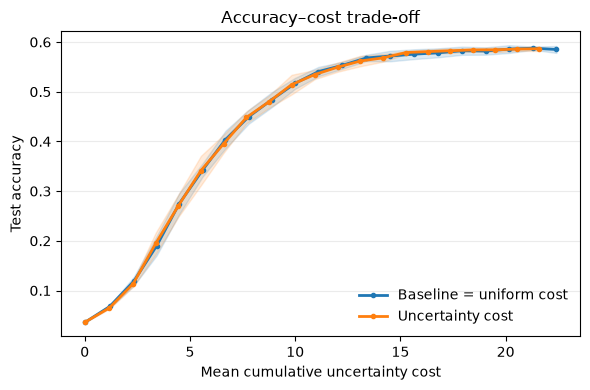

In [9]:
import matplotlib.pyplot as plt
from scipy.stats import t


curve_by_seed = (
    curve_details.groupby(["run_name", "seed", "step"])
    .apply(lambda g: pd.Series({
        "accuracy": accuracy_score(g["label"], g["prediction"]),
        "mean_cost": g["cumulative_cost"].mean(),
    }))
    .reset_index()
)

curve_summary = (
    curve_by_seed.groupby(["run_name", "step"])
    .agg(
        mean_cost=("mean_cost", "mean"),
        accuracy=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        n=("seed", "nunique"),
    )
    .reset_index()
)
curve_summary["ci95"] = (
    t.ppf(0.975, curve_summary["n"] - 1)
    * curve_summary["accuracy_std"]
    / np.sqrt(curve_summary["n"])
)

fig, ax = plt.subplots(figsize=(6, 4))
for name, label in [
    ("baseline", "Baseline = uniform cost"),
    ("uncertainty_cost", "Uncertainty cost"),
]:
    data = curve_summary[curve_summary["run_name"].eq(name)]
    line, = ax.plot(
        data["mean_cost"], data["accuracy"],
        marker="o", markersize=3, linewidth=2, label=label,
    )
    ax.fill_between(
        data["mean_cost"],
        data["accuracy"] - data["ci95"],
        data["accuracy"] + data["ci95"],
        color=line.get_color(), alpha=0.15,
    )

ax.set_xlabel("Mean cumulative uncertainty cost")
ax.set_ylabel("Test accuracy")
ax.set_title("Accuracy–cost trade-off")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


## Cost-feasible budget sweep

For each cost budget `B`, the cost-feasible candidate set excludes any query whose
execution would increase transcript cost beyond `B`. A rollout terminates when no feasible
query remains. The sweep reports accuracy and mean realized cost on a fixed test subset.
The confidence threshold is set above one so that the cost budget is the only stopping
criterion.


In [12]:
len(test_answers)

2000

In [13]:
COST_BUDGETS = [4, 8, 12, 16, 20]

test_answers = torch.tensor(qa_answers["test"], dtype=torch.float32, device=device)
test_labels = y_by_split["test"]
SUBSET_SIZE = len(test_answers) # set to 400 or lower for test
subset = np.arange(min(SUBSET_SIZE, test_answers.size(0)))


@torch.no_grad()
def budget_sweep(run, meter_cost, budgets, subset_indices):
    bundle = {"actor": run["actor"], "classifier": run["classifier"]}
    run["actor"].eval()
    run["classifier"].eval()
    rows = []
    for budget in budgets:
        preds = []
        costs = []
        query_counts = []
        sensitive_counts = []
        exhausted = []
        for i in subset_indices:
            answers_row = test_answers[i]
            init_mask = torch.zeros(1, len(concept_names), device=device)
            result = rollout_until_confidence(
                bundle=bundle,
                answers_row=answers_row,
                init_mask=init_mask,
                concepts=concept_names,
                sensitive_mask=sensitive_mask_vec,
                class_names=class_names,
                threshold=1.01,  # disable confidence stopping; budget is the only limit
                max_steps=MAX_QUESTIONS,
                cost_vector=meter_cost,
                cost_budget=float(budget),
            )
            preds.append(result["final_pred_idx"])
            costs.append(result["total_cost"])
            query_counts.append(result["queries_asked"])
            sensitive_counts.append(result["sensitive_steps"])
            exhausted.append(result["stop_reason"] == "cost_exhausted")
        rows.append(
            {
                "run_name": run["run_name"],
                "seed": run["seed"],
                "cost_budget": budget,
                "accuracy": accuracy_score(test_labels[subset_indices], preds),
                "mean_realized_cost": float(np.mean(costs)),
                "mean_queries": float(np.mean(query_counts)),
                "mean_sensitive_queries": float(np.mean(sensitive_counts)),
                "cost_exhaustion_rate": float(np.mean(exhausted)),
            }
        )
    return pd.DataFrame(rows)


budget_results_by_seed = pd.concat(
    [
        budget_sweep(run, uncertainty_cost, COST_BUDGETS, subset)
        for seed_runs in runs_by_seed.values()
        for run in seed_runs.values()
    ],
    ignore_index=True,
)
budget_results = budget_results_by_seed.groupby(["run_name", "cost_budget"]).agg(
    seeds=("seed", "nunique"),
    accuracy_mean=("accuracy", "mean"),
    accuracy_std=("accuracy", "std"),
    mean_realized_cost=("mean_realized_cost", "mean"),
    mean_queries=("mean_queries", "mean"),
    mean_sensitive_queries=("mean_sensitive_queries", "mean"),
    cost_exhaustion_rate=("cost_exhaustion_rate", "mean"),
).reset_index()
budget_results


,run_name,cost_budget,seeds,accuracy_mean,accuracy_std,mean_realized_cost,mean_queries,mean_sensitive_queries,cost_exhaustion_rate
0,baseline,4,5,0.1900,0.015704,3.417583,3.0000,0.0000,1.0
1,baseline,8,5,0.4381,0.017558,7.621066,6.8599,0.0319,1.0
2,baseline,12,5,0.5472,0.008431,11.506904,10.3724,0.0470,1.0
3,baseline,16,5,0.5754,0.008234,15.655132,14.0000,0.0000,1.0
4,baseline,20,5,0.5861,0.006368,19.449970,17.3836,0.0684,1.0
5,uncertainty_cost,4,5,0.1947,0.017488,3.371723,3.0000,0.0000,1.0
6,uncertainty_cost,8,5,0.4488,0.009478,7.666648,6.9969,0.0000,1.0
7,uncertainty_cost,12,5,0.5485,0.002031,11.716775,10.7470,0.0297,1.0
8,uncertainty_cost,16,5,0.5789,0.002434,15.517162,14.2426,0.0332,1.0
9,uncertainty_cost,20,5,0.5842,0.004102,19.566787,18.0923,0.0777,1.0


In [14]:
history_all = pd.concat(
    [run["history"] for seed_runs in runs_by_seed.values() for run in seed_runs.values()],
    ignore_index=True,
)
screening_history = pd.concat(
    [run["history"] for run in screening_runs.values()],
    ignore_index=True,
)
history_all.to_csv(runs_dir / "bias_in_bios_cost_experiment_history.csv", index=False)
screening_history.to_csv(runs_dir / "bias_in_bios_cost_lambda_sweep_history.csv", index=False)
lambda_sweep_summary.to_csv(runs_dir / "bias_in_bios_cost_lambda_sweep_summary.csv", index=False)
cost_summary_by_seed.to_csv(runs_dir / "bias_in_bios_cost_experiment_summary.csv", index=False)
budget_results_by_seed.to_csv(runs_dir / "bias_in_bios_cost_budget_sweep.csv", index=False)
cost_table.to_csv(runs_dir / "bias_in_bios_cost_vectors.csv", index=False)
print("saved:", sorted(p.name for p in runs_dir.glob("bias_in_bios_cost_*.csv")))


saved: ['bias_in_bios_cost_budget_sweep.csv', 'bias_in_bios_cost_experiment_history.csv', 'bias_in_bios_cost_experiment_summary.csv', 'bias_in_bios_cost_lambda_sweep_history.csv', 'bias_in_bios_cost_lambda_sweep_summary.csv', 'bias_in_bios_cost_vectors.csv']


## Experimental controls and interpretation

- `LAMBDA_C_CANDIDATES` is screened with `SCREENING_SEED` on validation rollouts. The test split
  is not used for hyperparameter selection.
- `COST_WEIGHT` is the selected `lambda_c`. Quantitative test results for that value are
  aggregated over the five seeds in `SEEDS`.
- Uniform cost has exactly zero actor gradient and therefore shares the baseline result; a
  redundant uniform-cost training run is omitted.
- The synthetic response-uncertainty condition provides a query-dependent cost signal. Its
  effect is assessed by comparing accuracy and macro F1 at matched cumulative cost, as well as
  realized cost at matched rollout depth.
- Prefix-level task supervision trains the classifier at every rollout horizon used by the
  budget sweep.
- The same uncertainty-cost vector meters the validation screening and all test comparisons.
- The designated-query weight and mask are identical across policy conditions. Sensitive-query
  counts are reported to verify that acquisition cost does not induce a degenerate preference
  for unit-cost designated queries.
- The cost-feasible budget sweep evaluates inference-time enforcement of the cumulative-cost
  constraint.
- The actor, task classifier, and auxiliary sensitive head are trained. The CLIP and
  Concept-QA models remain fixed across all conditions.
- `DESIGNATED_QUERY_WEIGHT` specifies `lambda_q`; `COST_BUDGETS` specifies the inference-time
  budgets.
- Cost feasibility is applied to the actor's full soft query ranking before the highest-ranked
  feasible query is selected. This permits a valid fallback when the unconstrained top query
  would exceed the remaining budget.
